In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.neighbors import NearestNeighbors
import pandas as pd
from tqdm import tqdm
import scienceplots
import sys
sys.path.append('/scratch/vdeltatt/imbalance-gain-causality')
from utilities import construct_time_delay_embedding
from dadapy.metric_comparisons import MetricComparisons

plt.style.use(['science','notebook'])

In [3]:
def autocorr2(x): # autocorrelation function
    r2=np.fft.ifft(np.abs(np.fft.fft(x))**2).real
    c=(r2/x.shape-np.mean(x)**2)/np.std(x)**2
    return c[:len(x)//2]

In [5]:
# read data
brain_data_subjects = pickle.load(open("./data/brain_data_part.pkl","rb"))
sfl_gpt2 = pickle.load(open("./data/sfl_gpt2.pkl","rb"))

print(f"Brain areas: {brain_data_subjects.keys()}")
print(f"Participants: {brain_data_subjects['all'].keys()}")
print(f"Shape of fmri data for given participant: {brain_data_subjects['all']['F'].shape}")
print(f"Shape of dependent data: {sfl_gpt2.shape}") # meaning of 12 components:
                                                    # 0:  surprisal(t)
                                                    # 1:  log(freq)(t)
                                                    # 2:  length(t)
                                                    # 3:  surprisal(t-1)
                                                    # 4:  log(freq)(t-1)
                                                    # 5:  length(t-1)
                                                    # 6:  surprisal(t-2)
                                                    # 7:  log(freq)(t-2)
                                                    # 8:  length(t-2)
                                                    # 9:  surprisal(t-3)
                                                    # 10: log(freq)(t-3)
                                                    # 11: length(t-3)

Brain areas: dict_keys(['all', 'PostTemp', 'AntTemp', 'AngularG', 'IFG', 'MFG', 'IFGorb', 'pCingulate'])
Participants: dict_keys(['F', 'H', 'I', 'J', 'K', 'L', 'M', 'N'])
Shape of fmri data for given participant: (1211,)
Shape of dependent data: (1211, 12)


Text(0.5, 1.0, 'Autocorrelation functions')

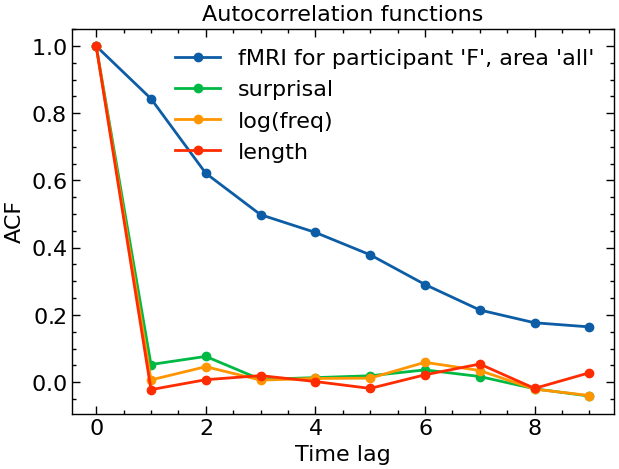

In [6]:
# Check decorrelation time of sample series
last_time = 15
plt.figure(figsize=(7,5))
plt.plot(autocorr2(brain_data_subjects['all']['F'])[:10],'o-', label="fMRI for participant 'F', area 'all'")
plt.plot(autocorr2(sfl_gpt2[:,0])[:10],'o-', label="surprisal")
plt.plot(autocorr2(sfl_gpt2[:,1])[:10],'o-', label="log(freq)")
plt.plot(autocorr2(sfl_gpt2[:,2])[:10],'o-', label="length")
plt.xlabel("Time lag")
plt.ylabel("ACF")
plt.legend()
plt.title("Autocorrelation functions")

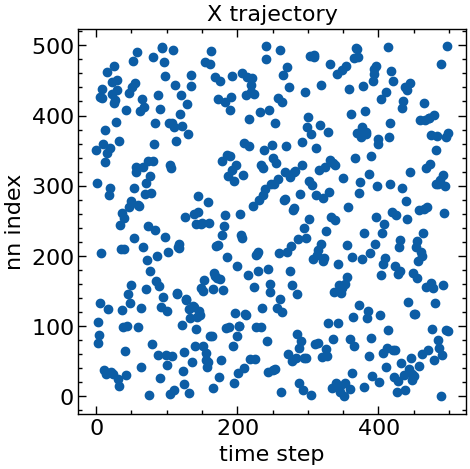

In [7]:
times = np.linspace(0,1210,500,dtype=int)

E = 3
tau_e = 1
X_time_delay = construct_time_delay_embedding(X=brain_data_subjects['all']['F'], E=E, tau_e=tau_e, sample_times=times)
N = X_time_delay.shape[0]

indices_nn_x = np.zeros(N)

nbrs_x = NearestNeighbors(n_neighbors=N).fit(X_time_delay)
_, indices_nn_x = nbrs_x.kneighbors(X_time_delay)
    
plt.rcParams['font.size'] = 16
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(indices_nn_x[:,1],'o')
ax.set(xlabel="time step", ylabel="nn index", title="X trajectory")
plt.show()

### $\Delta(Y(0) \rightarrow Y(\tau))$

In [13]:
taus = np.arange(20)
times = np.linspace(0,1211-taus[-1]-1,500,dtype=int)
E = 3
tau_e = 1

Y0 = construct_time_delay_embedding(X=brain_data_subjects['all']['F'], E=E, tau_e=tau_e, sample_times=times)
N = Y0.shape[0]

info_imbalances_vs_tau = np.zeros((len(taus),2))
for i_tau, tau in tqdm(enumerate(taus)):
    Ytau = construct_time_delay_embedding(X=brain_data_subjects['all']['F'], E=E, tau_e=tau_e, sample_times=times+tau)

    d = MetricComparisons(np.column_stack((Y0,Ytau)), maxk=N-1)
    info_imbalances_vs_tau[i_tau] = d.return_inf_imb_two_selected_coords(coords1=np.arange(E), coords2=np.arange(E,2*E), k=25)

20it [00:16,  1.25it/s]


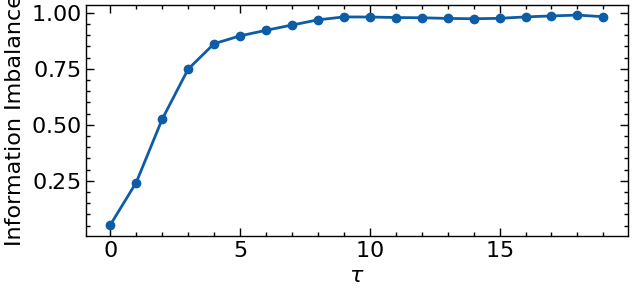

In [16]:
plt.figure(figsize=(7,3))
plt.plot(taus, info_imbalances_vs_tau[:,0], '-o')
plt.xlabel("$\\tau $")
plt.ylabel("Information Imbalance")
plt.show()

### Try Imbalance Gain

In [33]:
taus = np.arange(0,20)
E = 3
tau_e = 1
alphas = np.linspace(0,1.5,100)
n_jobs = 4
k = 25

X = brain_data_subjects['all']['F'] / np.std(brain_data_subjects['all']['F'])
Y = sfl_gpt2[:,0] / np.std(sfl_gpt2[:,0])

X_time_delay = construct_time_delay_embedding(X=X, E=E, tau_e=tau_e)
Y_time_delay = construct_time_delay_embedding(X=Y, E=E, tau_e=tau_e)

sample_times = np.linspace(0,X_time_delay.shape[0]-np.max(taus)-1,500,dtype=int)
X0 = X_time_delay[sample_times]
Y0 = Y_time_delay[sample_times]

info_imbalances_X_to_Y = np.zeros((len(taus),len(alphas)))
info_imbalances_Y_to_X = np.zeros((len(taus),len(alphas)))
for i_tau, tau in tqdm(enumerate(taus)):
    Xtau = X_time_delay[sample_times+tau]
    Ytau = Y_time_delay[sample_times+tau]

    d = MetricComparisons(maxk=len(sample_times)-1, njobs=n_jobs)
    info_imbalances_X_to_Y[i_tau] = d.return_inf_imb_causality(
        cause_present=X0, effect_present=Y0, effect_future=Ytau, weights=alphas, k=k)
    info_imbalances_Y_to_X[i_tau] = d.return_inf_imb_causality(
        cause_present=Y0, effect_present=X0, effect_future=Xtau, weights=alphas, k=k)

0it [00:00, ?it/s]

19it [20:22, 64.34s/it]


IndexError: index 1208 is out of bounds for axis 0 with size 1208

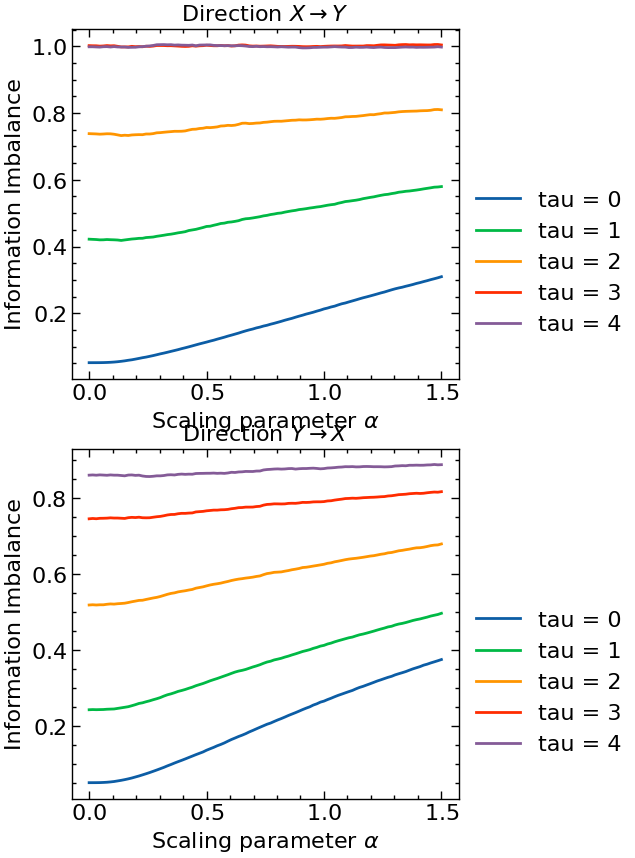

In [38]:
fig, ax = plt.subplots(2,1,figsize=(5,10))
for i_tau, tau in enumerate(taus[:-15]):
    ax[0].plot(alphas, info_imbalances_X_to_Y[i_tau], label=f"tau = {tau}")
    ax[1].plot(alphas, info_imbalances_Y_to_X[i_tau], label=f"tau = {tau}")
ax[0].set(xlabel="Scaling parameter $\\alpha$", ylabel="Information Imbalance", title="Direction $X\\rightarrow Y$")
ax[0].legend(loc=(1.02,0.1))
ax[1].set(xlabel="Scaling parameter $\\alpha$", ylabel="Information Imbalance", title="Direction $Y\\rightarrow X$")
ax[1].legend(loc=(1.02,0.1))
plt.show()

/tmp/ipykernel_4824/3984670776.py:1: RuntimeWarning: invalid value encountered in divide
  IGs_X_to_Y = (info_imbalances_X_to_Y[:,0] - np.min(info_imbalances_X_to_Y, axis=-1)) / info_imbalances_X_to_Y[:,0]
/tmp/ipykernel_4824/3984670776.py:2: RuntimeWarning: invalid value encountered in divide
  IGs_Y_to_X = (info_imbalances_Y_to_X[:,0] - np.min(info_imbalances_Y_to_X, axis=-1)) / info_imbalances_Y_to_X[:,0]


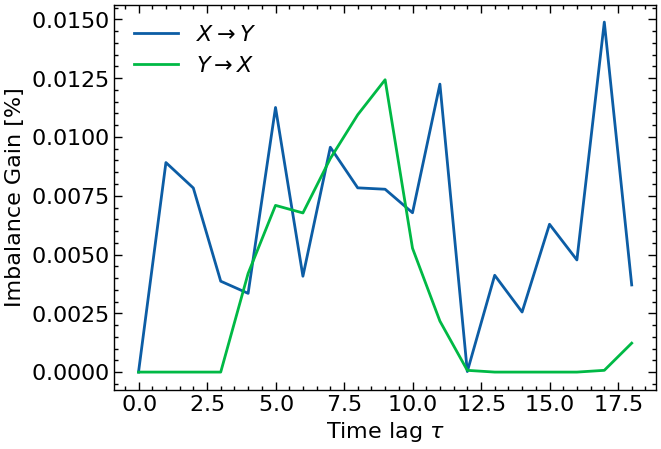

In [36]:
IGs_X_to_Y = (info_imbalances_X_to_Y[:,0] - np.min(info_imbalances_X_to_Y, axis=-1)) / info_imbalances_X_to_Y[:,0]
IGs_Y_to_X = (info_imbalances_Y_to_X[:,0] - np.min(info_imbalances_Y_to_X, axis=-1)) / info_imbalances_Y_to_X[:,0]

plt.figure(figsize=(7,5))
plt.plot(taus[:-1], IGs_X_to_Y[:-1], label="$X\\rightarrow Y$")
plt.plot(taus[:-1], IGs_Y_to_X[:-1], label="$Y\\rightarrow X$")
plt.xlabel("Time lag $\\tau$")
plt.ylabel("Imbalance Gain [%]")
plt.legend()
plt.show()